In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad

In [2]:
# Physical constants

e_charge = 1.602e-19  # C
mu_air = 1.00000037*c.mu0.value
muon_mass = (105.65837 * u.MeV/c.c**2).to(u.kg).value  # kg
muon_lifetime = 2.19698e-6  # s

blue_UV = 380e-9  # m
UVB_UVC = 280e-9  # m
# UV_limit = 250e-9  # m

P_std = 101325  # Pa
T_15C = 288.15  # K

atmos_height = 112.8e3  # m
# atmos_height = 11e3  # m  # relevant height

# dry_adiab_lapse_rate = 9.76e-3  # K / m
# molar_mass_dry_air = 0.02896968  # kg/mol

In [3]:
# VERITAS constants

# PMT_min = 185e-9  # m
# PMT_max = 650e-9  # m
# constant_efficiency_factor = 0.88 * 0.97

# D = 12  # m

veritas_alt = 1268  # m

In [4]:
def n_air(nu, alt=veritas_alt):

    lam = c.c.value / nu
    
    # Empirically determined constants
    A = 2.73e-4 
    B = 1.23e-18  # m^2
    C = 3.56e-32  # m^4
    
    # Scale height of the atmosphere
    h_0 = 8.4e3  # m

    epsilon_0 = A + B/lam**2 + C/lam**4
    epsilon = epsilon_0 * np.exp(-alt / h_0)
    
    return 1 + epsilon

In [5]:
def d2Edxdnu(nu, beta, q=1.602e-19, mu=1.00000037*c.mu0.value):

    return np.pi * q ** 2 * mu * nu * (1 - 1 / (beta * n_air(nu))**2)

In [6]:
def d2Ndxdnu(nu, beta, q=1.602e-19, mu=1.00000037*c.mu0.value):

    return np.pi * q ** 2 * mu / c.h.value * (1 - 1 / (beta * n_air(nu))**2)

In [7]:
def dEdx(nu_low, nu_high, beta, q=1.602e-19, mu=1.00000037*c.mu0.value):

    return quad(d2Edxdnu, nu_low, nu_high, args=(beta, q, mu))[0]

In [8]:
def dNdx(nu_low, nu_high, beta, q=1.602e-19, mu=1.00000037*c.mu0.value):

    return quad(d2Ndxdnu, nu_low, nu_high, args=(beta, q, mu))[0]

In [9]:
def get_beta(E, m=c.m_e.value):

    return np.sqrt(1 - m**2 * c.c.value**4 / E**2)

In [10]:
# Index of refraction at UVB-UVC limit for VERITAS altitude
n_air(c.c.value / UVB_UVC)

1.000253220552479

In [11]:
# Minimum muon energy (in GeV) to emit Cherenkov radiation in air
(1 - n_air(c.c.value / UVB_UVC)**-2)**-0.5 * muon_mass * c.c.value**2 * u.J.to(u.GeV)

4.695933084286152

In [12]:
# # Shower energy drop

# E = 1  # starting gamma energy in TeV

# E /= 2
# bet = get_beta(E * u.TeV.to(u.J))

# n = 1
# while bet > 1/n_air(c.c.value / UVB_UVC):
#     print(n, '--', E, 'TeV: beta =', bet)
#     n += 1
#     E /= 2
#     bet = get_beta(E * u.TeV.to(u.J))

In [13]:
cwavlg = (c.c.value/700e-9, c.c.value/250e-9)
cwavlg

(428274940000000.0, 1199169832000000.0)

In [14]:
np.log10(cwavlg)

array([14.63172266, 15.07888069])

In [15]:
freqs = np.logspace(12.8, 15.2, 10000)

# freqs = np.logspace(*np.log10(cwavlg), 10000)

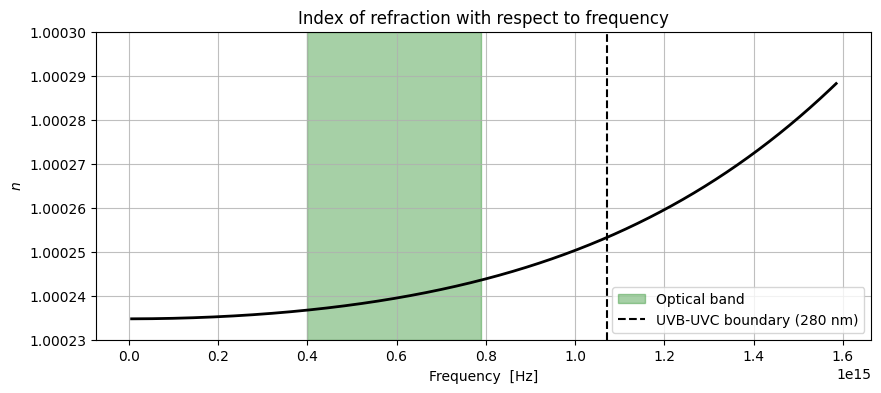

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(freqs, n_air(freqs), c='black', lw=2)
plt.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
plt.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

plt.grid(alpha=0.8)
plt.xlabel('Frequency  [Hz]')
plt.ylabel(r'$n$')
plt.title('Index of refraction with respect to frequency')

ticks = ax.yaxis.axes.get_yticks()
ticks_str = [f'%.5f' % tick for tick in ticks]
plt.yticks(ticks=ticks, labels=ticks_str)

plt.legend()
plt.show()

In [17]:
beta = get_beta(E=1 * u.TeV.to(u.J), m=muon_mass)  # 1-TeV muon

In [18]:
lams = np.array([50, 10, 5, 1])  # mcm

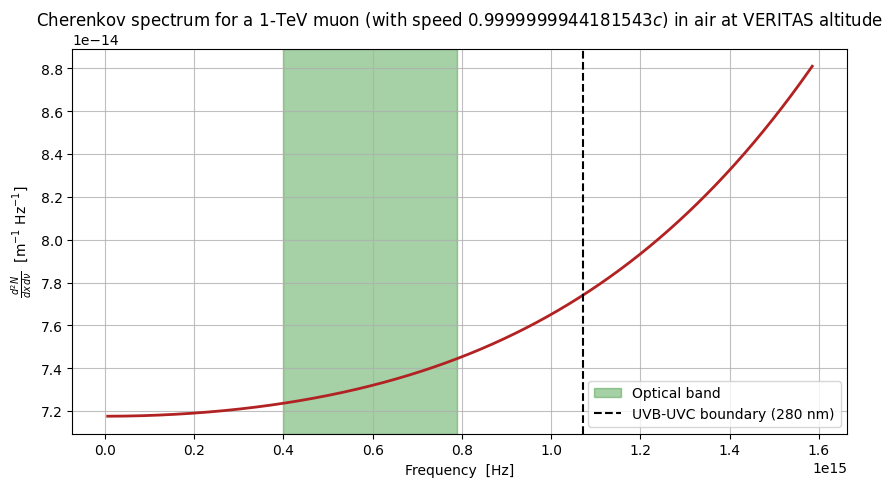

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(freqs, d2Ndxdnu(freqs, beta), c='firebrick', lw=2)
plt.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
plt.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

plt.grid(alpha=0.8)
plt.xlabel('Frequency  [Hz]')
plt.ylabel(r'$\frac{d^2N}{dx\,d\nu}$  [m$^{-1}$ Hz$^{-1}$]')
plt.title('Cherenkov spectrum for a 1-TeV muon (with speed ' + str(beta) + r'$c$) in air at VERITAS altitude')

plt.legend()
plt.show()

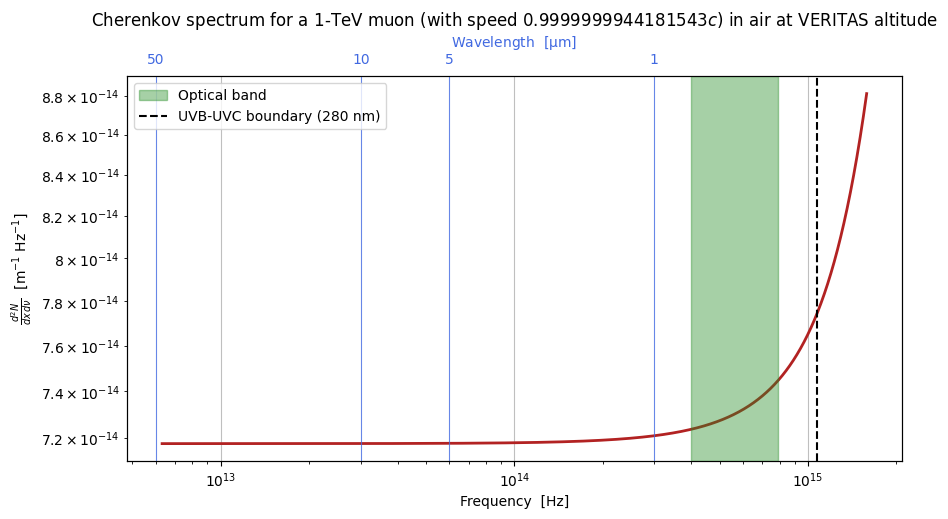

In [20]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

ax1.plot(freqs, d2Ndxdnu(freqs, beta), c='firebrick', lw=2)
ax2.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
ax2.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

ax1.grid(alpha=0.8)
ax1.set_xlabel('Frequency  [Hz]')
ax1.set_ylabel(r'$\frac{d^2N}{dx\,d\nu}$  [m$^{-1}$ Hz$^{-1}$]')
ax1.set_title('Cherenkov spectrum for a 1-TeV muon (with speed ' + str(beta) + r'$c$) in air at VERITAS altitude')


ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xscale('log')
ax2.xaxis.set_ticks_position('none') 
ax2.set_xticks(ticks=c.c.value / (lams * 1e-6), color='royalblue', labels=lams)
ax2.set_xlim(ax1.get_xlim())
ax2.grid(alpha=0.8, color='royalblue')
ax2.set_xlabel(r'Wavelength  [$\mathrm{\mu}$m]', color='royalblue')

ax2.legend(loc='upper left')
plt.show()

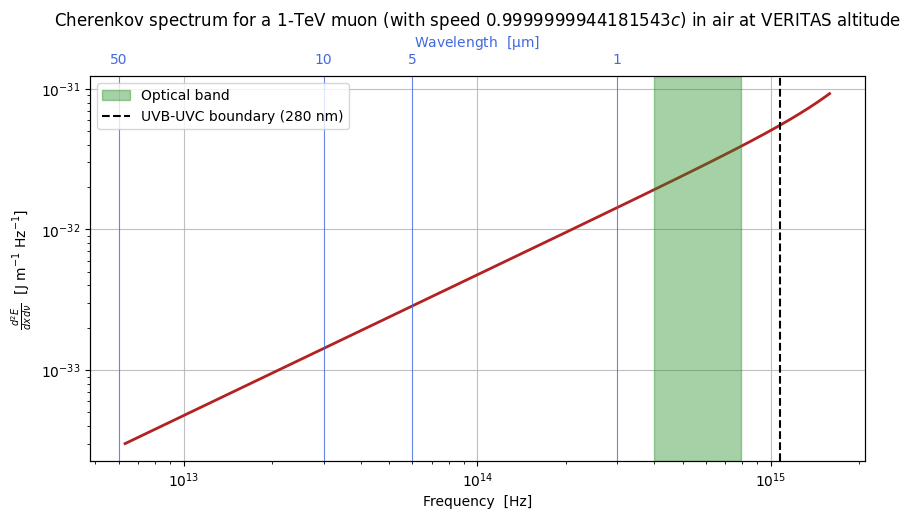

In [21]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

ax1.plot(freqs, d2Edxdnu(freqs, beta), c='firebrick', lw=2)
ax2.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
ax2.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

ax1.grid(alpha=0.8)
ax1.set_xlabel('Frequency  [Hz]')
ax1.set_ylabel(r'$\frac{d^2E}{dx\,d\nu}$  [J m$^{-1}$ Hz$^{-1}$]')
ax1.set_title('Cherenkov spectrum for a 1-TeV muon (with speed ' + str(beta) + r'$c$) in air at VERITAS altitude')

ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlim(ax1.get_xlim())
ax2.set_xscale('log')
ax2.xaxis.set_ticks_position('none') 
ax2.set_xticks(ticks=c.c.value / (lams * 1e-6), color='royalblue', labels=lams)
ax2.grid(alpha=0.8, color='royalblue')
ax2.set_xlabel(r'Wavelength  [$\mathrm{\mu}$m]', color='royalblue')

ax2.legend(loc='upper left')
plt.show()

In [22]:
total_N = dNdx(0, 1.1e15, beta)
print('Number of Cherenkov photons emitted per meter by a muon travelling through air with speed '
      + str(beta) + 'c:', total_N)

Number of Cherenkov photons emitted per meter by a muon travelling through air with speed 0.9999999944181543c: 80.90786433397624


In [23]:
total_E = dEdx(0, 1.1e15, beta)
print('Total energy radiated per meter by a muon travelling through air with speed '
      + str(beta) + 'c:', total_E, 'J')

Total energy radiated per meter by a muon travelling through air with speed 0.9999999944181543c: 2.9866928778736776e-17 J


In [24]:
energies = np.array([4.9, 5, 6, 7, 10, 100, 1000])  # GeV
betas = get_beta(E=energies * u.GeV.to(u.J), m=muon_mass)  # muons
betas

array([0.99976749, 0.9997767 , 0.99984494, 0.99988608, 0.99994418,
       0.99999944, 0.99999999])

In [25]:
(1 - betas[-2]**2)**-0.5

946.4465522039596

In [26]:
clrs = ['firebrick', 'gold', 'limegreen', 'dodgerblue', 'blueviolet', 'fuchsia']

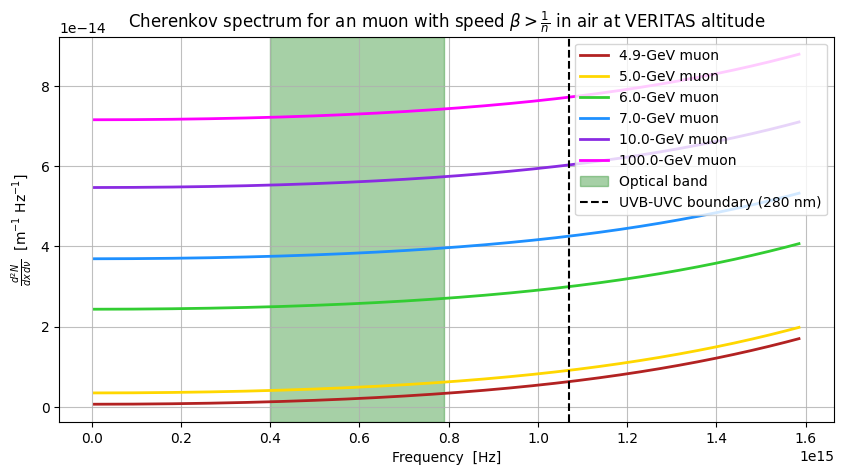

In [27]:
plt.figure(figsize=(10, 5))

for i, b in enumerate(betas[:-1]):
    plt.plot(freqs, d2Ndxdnu(freqs, b), c=clrs[i], lw=2, label=str(energies[i]) + '-GeV muon')
plt.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
plt.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

plt.grid(alpha=0.8)
plt.xlabel('Frequency  [Hz]')
plt.ylabel(r'$\frac{d^2N}{dx\,d\nu}$  [m$^{-1}$ Hz$^{-1}$]')
plt.title(r'Cherenkov spectrum for an muon with speed $\beta > \frac{1}{n}$ in air at VERITAS altitude')

plt.legend()
plt.show()

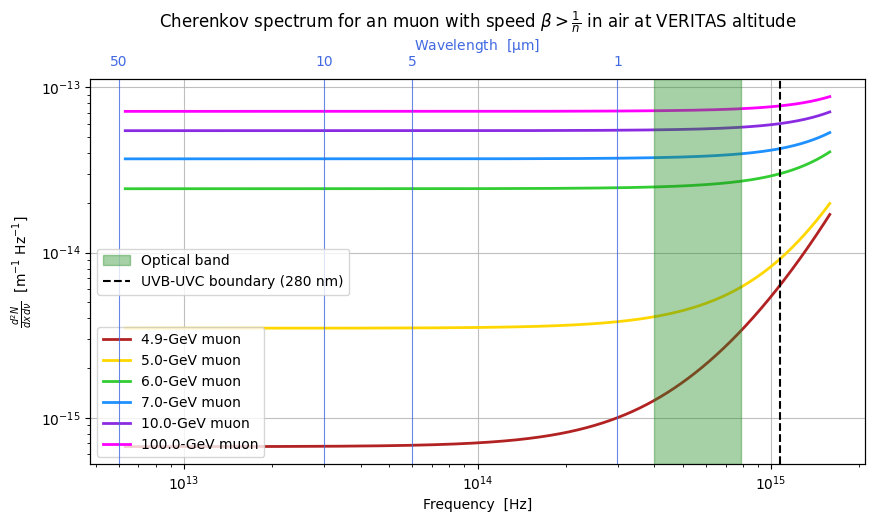

In [28]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

for i, b in enumerate(betas[:-1]):
    ax1.plot(freqs, d2Ndxdnu(freqs, b), c=clrs[i], lw=2, label=str(energies[i]) + '-GeV muon')
ax2.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
ax2.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

ax1.grid(alpha=0.8)
ax1.set_xlabel('Frequency  [Hz]')
ax1.set_ylabel(r'$\frac{d^2N}{dx\,d\nu}$  [m$^{-1}$ Hz$^{-1}$]')
plt.title(r'Cherenkov spectrum for an muon with speed $\beta > \frac{1}{n}$ in air at VERITAS altitude')

ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlim(ax1.get_xlim())
ax2.set_xscale('log')
ax2.xaxis.set_ticks_position('none') 
ax2.set_xticks(ticks=c.c.value / (lams * 1e-6), color='royalblue', labels=lams)
ax2.grid(alpha=0.8, color='royalblue')
ax2.set_xlabel(r'Wavelength  [$\mathrm{\mu}$m]', color='royalblue')

ax1.legend(loc='lower left')
ax2.legend(loc='center left')
plt.show()

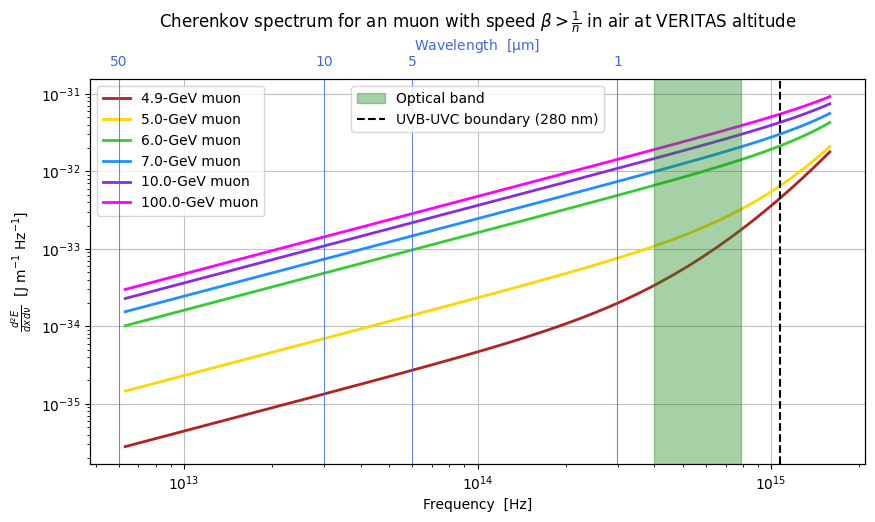

In [29]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

for i, b in enumerate(betas[:-1]):
    ax1.plot(freqs, d2Edxdnu(freqs, b), c=clrs[i], lw=2, label=str(energies[i]) + '-GeV muon')
ax2.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
ax2.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

ax1.grid(alpha=0.8)
ax1.set_xlabel('Frequency  [Hz]')
ax1.set_ylabel(r'$\frac{d^2E}{dx\,d\nu}$  [J m$^{-1}$ Hz$^{-1}$]')
plt.title(r'Cherenkov spectrum for an muon with speed $\beta > \frac{1}{n}$ in air at VERITAS altitude')

ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlim(ax1.get_xlim())
ax2.set_xscale('log')
ax2.xaxis.set_ticks_position('none') 
ax2.set_xticks(ticks=c.c.value / (lams * 1e-6), color='royalblue', labels=lams)
ax2.grid(alpha=0.8, color='royalblue')
ax2.set_xlabel(r'Wavelength  [$\mathrm{\mu}$m]', color='royalblue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
plt.show()

In [30]:
def d2Edxdnu_MM(nu, beta, mu=1.00000037*c.mu0.value):

    return np.pi * 1.602e-19 ** 2 * mu * nu * (1 - 1 / (beta * n_air(nu))**2) * (n_air(nu) / (2 * c.alpha)) ** 2

In [31]:
def d2Ndxdnu_MM(nu, beta, mu=1.00000037*c.mu0.value):

    return np.pi * 1.602e-19 ** 2 * mu /c.h.value * (1 - 1 / (beta * n_air(nu))**2) * (n_air(nu) / (2 * c.alpha)) ** 2

In [32]:
def dEdx_MM(nu_low, nu_high, beta, mu=1.00000037*c.mu0.value):

    return quad(d2Edxdnu_MM, nu_low, nu_high, args=(beta, mu))[0]

In [33]:
def dNdx_MM(nu_low, nu_high, beta, mu=1.00000037*c.mu0.value):

    return quad(d2Ndxdnu_MM, nu_low, nu_high, args=(beta, mu))[0]

In [34]:
gamma = (1 - n_air(c.c.value / UVB_UVC)**-2)**-0.5
gamma

44.44449677092456

In [35]:
# pick gamma = 1e3
# e.g. MM with mass 1e5 GeV, requires E = 1e8 GeV
# MM with mass 1e8 GeV, requires E = 1e11 GeV, etc.

In [36]:
beta_MM = get_beta(E=1e11 * u.GeV.to(u.J), m=(1e8 * c.c**-2 *u.GeV).to(u.kg).value) 

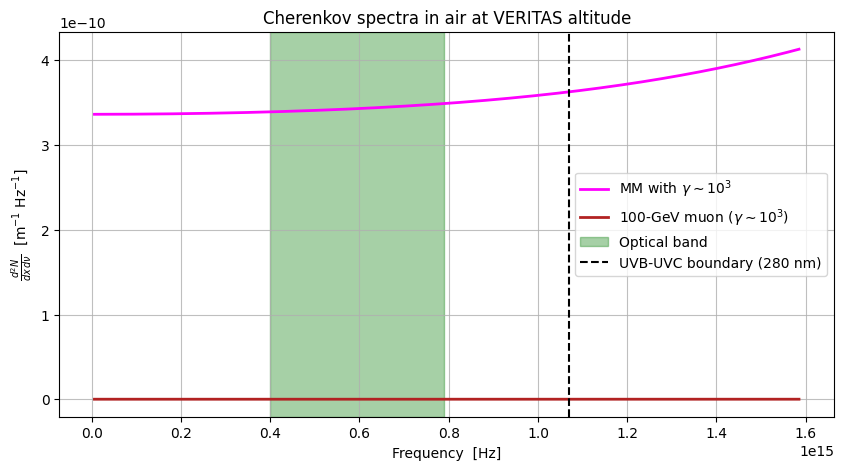

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(freqs, d2Ndxdnu_MM(freqs, beta_MM), c='fuchsia', lw=2, label=r'MM with $\gamma \sim 10^3$')
plt.plot(freqs, d2Ndxdnu(freqs, betas[-2]), c='firebrick', lw=2, label=r'100-GeV muon ($\gamma \sim 10^3$)')
plt.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
plt.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

plt.grid(alpha=0.8)
plt.xlabel('Frequency  [Hz]')
plt.ylabel(r'$\frac{d^2N}{dx\,d\nu}$  [m$^{-1}$ Hz$^{-1}$]')
plt.title('Cherenkov spectra in air at VERITAS altitude')

plt.legend()
plt.show()

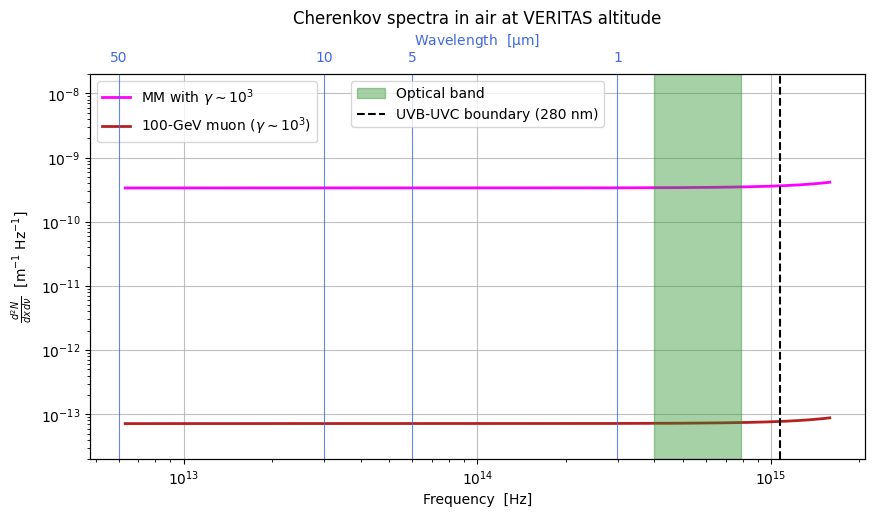

In [38]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

ax1.plot(freqs, d2Ndxdnu_MM(freqs, beta_MM), c='fuchsia', lw=2, label=r'MM with $\gamma \sim 10^3$')
ax1.plot(freqs, d2Ndxdnu(freqs, betas[-2]), c='firebrick', lw=2, label=r'100-GeV muon ($\gamma \sim 10^3$)')
ax2.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
ax2.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

ax1.grid(alpha=0.8)
ax1.set_xlabel('Frequency  [Hz]')
ax1.set_ylabel(r'$\frac{d^2N}{dx\,d\nu}$  [m$^{-1}$ Hz$^{-1}$]')
ax1.set_title('Cherenkov spectra in air at VERITAS altitude')

ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlim(ax1.get_xlim())
ax2.set_xscale('log')
ax2.xaxis.set_ticks_position('none') 
ax2.set_xticks(ticks=c.c.value / (lams * 1e-6), color='royalblue', labels=lams)
ax2.grid(alpha=0.8, color='royalblue')
ax2.set_xlabel(r'Wavelength  [$\mathrm{\mu}$m]', color='royalblue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')

ax1.set_ylim(2e-14, 2e-8)
plt.show()

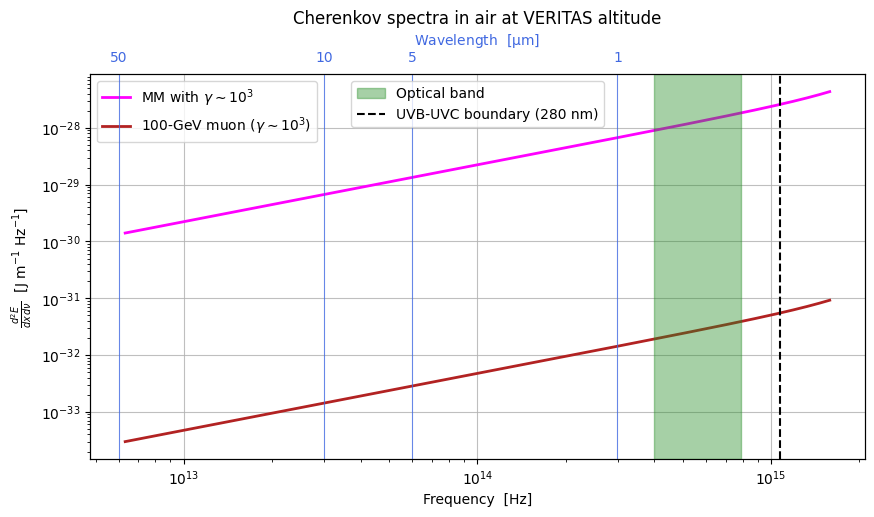

In [39]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

ax1.plot(freqs, d2Edxdnu_MM(freqs, beta_MM), c='fuchsia', lw=2, label=r'MM with $\gamma \sim 10^3$')
ax1.plot(freqs, d2Edxdnu(freqs, betas[-2]), c='firebrick', lw=2, label=r'100-GeV muon ($\gamma \sim 10^3$)')
ax2.axvspan(c.c.value / 750e-9, c.c.value / 380e-9, color='forestgreen', alpha=0.4, label='Optical band')
ax2.axvline(x=c.c.value / 280e-9, color='black', ls='--', lw=1.5, label='UVB-UVC boundary (280 nm)')

ax1.grid(alpha=0.8)
ax1.set_xlabel('Frequency  [Hz]')
ax1.set_ylabel(r'$\frac{d^2E}{dx\,d\nu}$  [J m$^{-1}$ Hz$^{-1}$]')
ax1.set_title('Cherenkov spectra in air at VERITAS altitude')

ax1.set_yscale('log')
ax1.set_xscale('log')

ax2.set_xlim(ax1.get_xlim())
ax2.set_xscale('log')
ax2.xaxis.set_ticks_position('none') 
ax2.set_xticks(ticks=c.c.value / (lams * 1e-6), color='royalblue', labels=lams)
ax2.grid(alpha=0.8, color='royalblue')
ax2.set_xlabel(r'Wavelength  [$\mathrm{\mu}$m]', color='royalblue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
plt.show()

In [40]:
total_N = dNdx(0, 1.1e15, betas[-2]) / 100
print('Number of Cherenkov photons emitted per cm by a muon travelling through air with speed '
      + str(betas[-2]) + 'c:', total_N)

total_N_MM = dNdx_MM(0, 1.1e15, beta_MM) / 100
print('Number of Cherenkov photons emitted per cm by a magnetic monopole travelling through air with speed '
      + str(beta_MM) + 'c:', total_N_MM)

Number of Cherenkov photons emitted per cm by a muon travelling through air with speed 0.9999994418152867c: 0.8072205988369021
Number of Cherenkov photons emitted per cm by a magnetic monopole travelling through air with speed 0.999999499999875c: 3792.4154460367495


In [41]:
total_N_MM / total_N

4698.115300205566

In [42]:
total_E = dEdx(0, 1.1e15, betas[-2]) / 100 * u.J.to(u.eV)
print('Total energy radiated per cm by a muon travelling through air with speed '
      + str(betas[-2]) + 'c:', total_E, 'eV')

total_E_MM = dEdx_MM(0, 1.1e15, beta_MM) / 100 * u.J.to(u.eV)
print('Total energy radiated per cm by a magnetic monopole travelling through air with speed '
      + str(beta_MM) + 'c:', total_E_MM / 1e3, 'keV')

Total energy radiated per cm by a muon travelling through air with speed 0.9999994418152867c: 1.8599207562481477 eV
Total energy radiated per cm by a magnetic monopole travelling through air with speed 0.999999499999875c: 8.738149453477078 keV


In [43]:
total_E_MM / total_E

4698.129973614449